# IMLP6 Task 04 — Predicția prețului unei mașini

EDA, curățarea datelor și pregătirea soluției de regresie.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "data" / "cars.csv"

from data_cleaning import load_data, clean_data
from feature_engineering import add_features

raw = load_data(DATA_PATH)
print("Shape:", raw.shape)
display(raw.head())

Shape: (56244, 12)


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


## 1. Structură, tipuri și valori lipsă

In [2]:
print("Tipuri de date:")
display(raw.dtypes.to_frame("dtype"))

missing = raw.isna().sum().to_frame("missing_values")
missing["missing_pct"] = (missing["missing_values"] / len(raw) * 100).round(2)
display(missing.sort_values("missing_values", ascending=False))

print("Duplicate exacte:", raw.duplicated().sum())

Tipuri de date:


,dtype
make,object
model,object
priceUSD,int64
year,int64
condition,object
mileage(kilometers),float64
fuel_type,object
volume(cm3),float64
color,object
transmission,object


,missing_values,missing_pct
segment,5291,9.41
drive_unit,1905,3.39
volume(cm3),47,0.08
make,0,0.00
year,0,0.00
priceUSD,0,0.00
model,0,0.00
condition,0,0.00
fuel_type,0,0.00
mileage(kilometers),0,0.00


Duplicate exacte: 87


## 2. Variabila țintă și coloanele numerice/categorice

In [3]:
target = "priceUSD"
numeric_cols = raw.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in raw.columns if c not in numeric_cols]
print("Target:", target)
print("Numerice:", numeric_cols)
print("Categorice:", categorical_cols)
display(raw[numeric_cols].describe().T)

Target: priceUSD
Numerice: ['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']
Categorice: ['make', 'model', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment']


,count,mean,std,min,25%,50%,75%,max
priceUSD,56244.0,7415.456440,8316.959261,48.0,2350.0,5350.0,9807.5,235235.0
year,56244.0,2003.454840,8.144247,1910.0,1998.0,2004.0,2010.0,2019.0
mileage(kilometers),56244.0,244395.631020,321030.668382,0.0,137000.0,228500.0,310000.0,9999999.0
volume(cm3),56197.0,2104.860615,959.201633,500.0,1600.0,1996.0,2300.0,20000.0


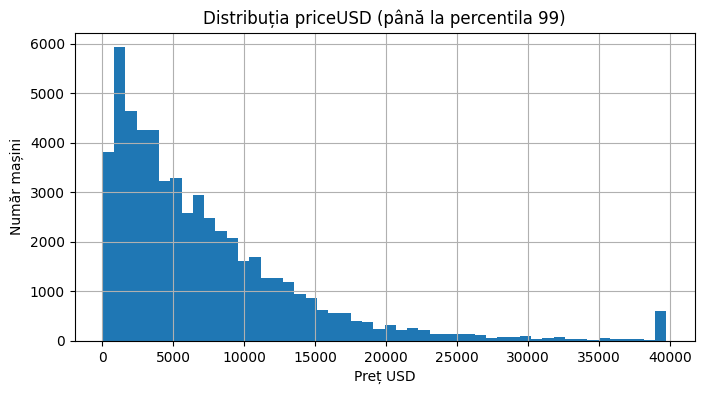

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
raw["priceUSD"].clip(upper=raw["priceUSD"].quantile(0.99)).hist(bins=50, ax=ax)
ax.set_title("Distribuția priceUSD (până la percentila 99)")
ax.set_xlabel("Preț USD")
ax.set_ylabel("Număr mașini")
plt.show()

## 3. Valori extreme și relații importante

In [5]:
quantiles = raw[["priceUSD", "year", "mileage(kilometers)", "volume(cm3)"]].quantile([0, .01, .5, .95, .99, .999, 1]).T
display(quantiles)
print("Kilometraj > 1.000.000 km:", int((raw["mileage(kilometers)"] > 1_000_000).sum()))
print("Cilindree > 8.000 cm3:", int((raw["volume(cm3)"] > 8000).sum()))

,0.000,0.010,0.500,0.950,0.990,0.999,1.000
priceUSD,48.0,333.0,5350.0,20000.0,39728.5,86975.700,235235.0
year,1910.0,1984.0,2004.0,2016.0,2018.0,2019.000,2019.0
mileage(kilometers),0.0,15.0,228500.0,431000.0,630000.0,4444504.046,9999999.0
volume(cm3),500.0,1000.0,1996.0,3500.0,5000.0,18000.000,20000.0


Kilometraj > 1.000.000 km: 364
Cilindree > 8.000 cm3: 88


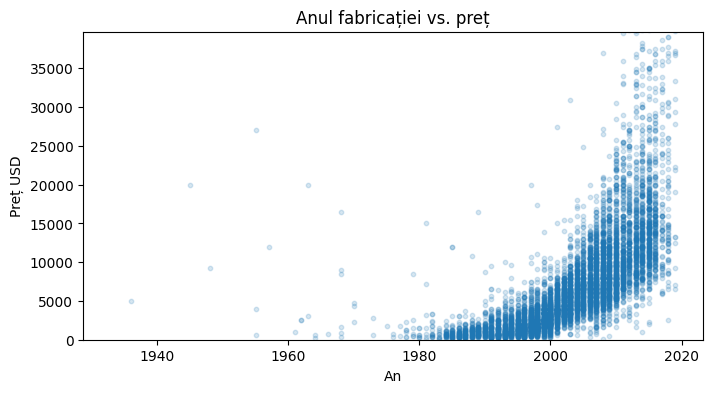

In [6]:
sample = raw.sample(min(8000, len(raw)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(sample["year"], sample["priceUSD"], alpha=0.18, s=10)
ax.set_ylim(0, raw["priceUSD"].quantile(.99))
ax.set_title("Anul fabricației vs. preț")
ax.set_xlabel("An")
ax.set_ylabel("Preț USD")
plt.show()

In [7]:
top_makes = raw.groupby("make")["priceUSD"].agg(["count", "median"]).query("count >= 200").sort_values("median", ascending=False).head(15)
display(top_makes)

,count,median
make,,
lexus,359,14950.0
land-rover,347,13000.0
infiniti,248,11200.0
toyota,2177,8650.0
bmw,4013,8300.0
volvo,1232,8100.0
skoda,1143,8000.0
chevrolet,595,8000.0
mercedes-benz,3541,7600.0


## 4. Curățare — decizii

- elimin duplicatele exacte;
- păstrez doar `priceUSD > 0` și ani plauzibili;
- kilometrajul peste 1.000.000 km este tratat ca valoare invalidă și lăsat pentru imputare;
- valorile de cilindree 16.000–20.000 cm³ sunt compatibile cu o eroare x10, deci sunt împărțite la 10;
- valorile lipsă ale predictorilor nu sunt completate manual înainte de split, pentru a evita leakage; sunt imputate în pipeline-ul sklearn.

In [8]:
cleaned = clean_data(raw)
print("Shape după curățare:", cleaned.shape)
print("Rânduri eliminate:", len(raw) - len(cleaned))
display(cleaned.head())
display(cleaned.isna().sum().sort_values(ascending=False).head(8).to_frame("missing_after_cleaning"))

Shape după curățare: (56157, 12)
Rânduri eliminate: 87


,make,model,price_usd,year,condition,mileage_km,fuel_type,engine_volume_cm3,color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,b
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,b
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,b
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,b
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,b


,missing_after_cleaning
mileage_km,363
engine_volume_cm3,47
make,0
model,0
year,0
price_usd,0
condition,0
fuel_type,0


## 5. Ingineria caracteristicilor

In [9]:
featured = add_features(cleaned)
new_features = ["car_age", "mileage_per_year", "engine_volume_liters", "is_newer_car", "is_high_mileage", "make_model"]
display(featured[["make", "model", "year", "mileage_km", "engine_volume_cm3"] + new_features].head(10))

,make,model,year,mileage_km,engine_volume_cm3,car_age,mileage_per_year,engine_volume_liters,is_newer_car,is_high_mileage,make_model
0,mazda,2,2008,162000.0,1500.0,18,9000.000000,1.5,0,0,mazda_2
1,mazda,2,2009,120000.0,1300.0,17,7058.823529,1.3,0,0,mazda_2
2,mazda,2,2009,61000.0,1500.0,17,3588.235294,1.5,0,0,mazda_2
3,mazda,2,2003,265000.0,1400.0,23,11521.739130,1.4,0,0,mazda_2
4,mazda,2,2008,97183.0,1400.0,18,5399.055556,1.4,0,0,mazda_2
5,mazda,2,2005,150000.0,1300.0,21,7142.857143,1.3,0,0,mazda_2
6,mazda,2,2008,112000.0,1300.0,18,6222.222222,1.3,0,0,mazda_2
7,mazda,2,2009,95000.0,1500.0,17,5588.235294,1.5,0,0,mazda_2
8,mazda,2,2010,93804.0,1500.0,16,5862.750000,1.5,0,0,mazda_2
9,mazda,2,2008,196511.0,1500.0,18,10917.277778,1.5,0,0,mazda_2


## 6. Concluzii EDA

Setul combină caracteristici numerice și categorice, are categorii cu cardinalitate ridicată (`model`, `make_model`) și câteva valori lipsă/extreme. Prețul este asimetric, iar anul, marca/modelul, kilometrajul și cilindreea sunt predictori utili. Soluția folosește imputare + scalare pentru numerice și encodare pentru categorice. Pentru comparația finală sunt testate Ridge, Random Forest și HistGradientBoosting, iar alegerea se face pe set test prin MAE, RMSE și R².